# Homework 3: Download and analyze any data using tools you learned in class

### IMPORTANT: Save your notebook and files (if you import locally) 
### IMPORTANT: See my example data folder: data/hw/hw_3/cory-baird
### **HW Requirements**

- **Relative Paths Only**
  - Use relative paths from the project root (e.g., `data/hw/hw_3/student-name/data.csv`).
  - Never hardcode absolute paths specific to your local machine (e.g., `/Users/username/...`).
- **File Size Limit**
  - Any committed dataset must be reasonable in size (strictly under 10 megabytes).
    - If you have to filter the dataset (to make it smaller) and upload a smaller version

- **Dataset Selection**
  - Select a policy-relevant dataset with at least 50 observations (e.g., 50 states, countries, or time periods) for meaningful analysis.
  - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Data Acquisition**
  - You are highly encouraged to fetch data programmatically using an API (e.g. using `requests` with World Bank, US Census, or other public APIs) or load a direct public URL.

  - Alternatively, you may upload a local file, provided it is committed to your repository.
    - If you read csv/parquet etc use relative paths such as `data/hw/hw_3/student-name/data.csv`.
    - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Reproducibility**
  - Commit both this notebook and the dataset so that your grader can run all cells from top to bottom out-of-the-box.

## IMPORTANT

---
### **Objectives**
- Select, acquire, and load a policy-relevant dataset of your choice.
- Apply clean code principles (environment checks, Python collections, standardized variable naming).
- Preprocess and standardize columns using Pandas techniques.
- Programmatically merge your primary dataset with a secondary source.
- Segment your data and run custom aggregations (using groupby or custom grouping strategies).
- Create customized visualizations and run exploratory regression analysis to discover policy insights.

### **Concept Reference Map**
- **Data Acquisition**: APIs (`requests` library), reading Parquet/CSV (Week 2/3 basics, Week 4 `1-visualization_basics.ipynb`)
- **Data Manipulation**: Selecting, renaming columns, filtering (`query()`), dropping NaNs (Week 4 `1-visualization_basics.ipynb`)
- **Aggregation**: Groupby, descriptive statistics (`describe()`, `mean()`) (Week 4 `1-visualization_basics.ipynb`)
- **Data Merging**: Pandas `merge()` matching indices or keys (Week 4 `2-merging_practice.ipynb`)
- **Visualization**: Scatter plots, line/bar charts, customization (Week 4 / Week 6 `1-regression.ipynb`)
- **Modeling**: Simple Linear Regression (`statsmodels`), line of best fit (Week 6 `1-regression.ipynb`)

---

### **Part 1: Data Acquisition & Environment Preparation**

- **Environment Setup**
  - Use python's `os` library (as reviewed in Week 3) to print your current working directory (`os.getcwd()`) and list the files in your project directory (`os.listdir()`) to ensure your paths are configured correctly.
- **Acquisition Steps**
  - Programmatically fetch data using `requests` or read directly from a public URL using Pandas.
  - If loading a committed local dataset, load it using a relative path.
- **Code Requirements**
  - Define variables using standardized, descriptive names.
  - Keep all function and method arguments on a single line.
  - Do not use docstrings (`""" """`) or runtime type checking in your helper methods.

In [1]:
import os
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import statsmodels.api as sm


# You can use example datasets here docs/example_datasets.md

# 1. Print environment details (working directory and local folder contents)
# If you read csv/parquet etc use relative paths such as data/hw/hw_3/student-name/data.csv
print("Current working directory:", os.getcwd())
print("Files in this folder:", os.listdir())

# Relative path to the committed data folder for this student
data_dir = "../../../data/hw/hw_3/hao-yuan"

# 2. Acquire and load your primary dataset
# Helper: pull one World Bank indicator for all countries in a single year
def fetch_wb_indicator(indicator_code, year):
    url = f"https://api.worldbank.org/v2/country/all/indicator/{indicator_code}?date={year}&format=json&per_page=400"
    response = requests.get(url, timeout=60)
    records = response.json()[1]
    frame = pd.json_normalize(records)
    frame = frame[["countryiso3code", "country.value", "date", "value"]]
    return frame.rename(columns={"country.value": "country"})

# Helper: list of "real" country codes so we can drop regional aggregates later
def fetch_real_country_codes():
    url = "https://api.worldbank.org/v2/country?format=json&per_page=400"
    meta = pd.json_normalize(requests.get(url, timeout=60).json()[1])
    return set(meta.loc[meta["region.value"] != "Aggregates", "id"])

# Try the live API first; fall back to the committed CSV so the notebook always runs top-to-bottom
try:
    gdp_raw = fetch_wb_indicator("NY.GDP.PCAP.CD", 2022)
    real_countries = fetch_real_country_codes()
    gdp_raw.to_csv(f"{data_dir}/wb_gdp_per_capita.csv", index=False)
    print("Loaded GDP per capita from the World Bank API")
except Exception as error:
    gdp_raw = pd.read_csv(f"{data_dir}/wb_gdp_per_capita.csv")
    real_countries = None
    print("API unavailable, loaded committed CSV instead:", error)

gdp_raw.head()

Current working directory: e:\classes\datascience-publicpolicy-2026\notebooks\hw\hw_3
Files in this folder: ['hw_3.ipynb']
Loaded GDP per capita from the World Bank API


,countryiso3code,country,date,value
0,AFE,Africa Eastern and Southern,2022,1679.327622
1,AFW,Africa Western and Central,2022,2138.473153
2,ARB,Arab World,2022,7950.355820
3,CSS,Caribbean small states,2022,17456.308485
4,CEB,Central Europe and the Baltics,2022,19530.155323


### **Dataset Context & Relevance**

- **Dataset Source**
  - Specify the source of your dataset (e.g., API name, public organization, or website URL).

**Source:** [World Bank Open Data](https://data.worldbank.org/) via the World Development Indicators (WDI) REST API.

- **Primary indicator:** GDP per capita, current US$ (`NY.GDP.PCAP.CD`), year 2022.
- **Secondary indicator:** Life expectancy at birth, total years (`SP.DYN.LE00.IN`), year 2022.

**Policy relevance:** Together these reproduce the classic *Preston curve* — the cross-country relationship between national income and population health. It speaks directly to development and public-health policy: how strongly does economic prosperity translate into longer lives, and where do the diminishing returns to income set in? The dataset covers 200+ countries, well above the 50-observation requirement.

### **Part 2: Data Cleaning & Preprocessing**

- **Data Inspection**
  - Inspect column names, data types, and non-null counts using `.info()` and `.head()`.
- **Preprocessing Tasks**
  - Select a subset of columns necessary for your policy inquiry.
  - Standardize column names to a clean formatting (preferably `snake_case` or another consistent style).
  - Identify and handle missing values (`NaN`s) by dropping or filling them.
- **Python Grammar Tip**
  - You are encouraged to use a Python dictionary (as reviewed in Week 2 & 3) to map and rename your column names cleanly.

In [2]:
# 1. Inspect data structure using pandas methods
gdp_raw.info()
gdp_raw.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   countryiso3code  266 non-null    object 
 1   country          266 non-null    object 
 2   date             266 non-null    object 
 3   value            257 non-null    float64
dtypes: float64(1), object(3)
memory usage: 8.4+ KB


,countryiso3code,country,date,value
0,AFE,Africa Eastern and Southern,2022,1679.327622
1,AFW,Africa Western and Central,2022,2138.473153
2,ARB,Arab World,2022,7950.355820
3,CSS,Caribbean small states,2022,17456.308485
4,CEB,Central Europe and the Baltics,2022,19530.155323


In [3]:
# 2. Rename columns and select a clean subset
# Use a dictionary to map the raw API column names to clean snake_case names
gdp_rename_map = {"countryiso3code": "country_code", "value": "gdp_per_capita"}
gdp = gdp_raw.rename(columns=gdp_rename_map)
gdp = gdp[["country_code", "country", "gdp_per_capita"]]
gdp.head()

,country_code,country,gdp_per_capita
0,AFE,Africa Eastern and Southern,1679.327622
1,AFW,Africa Western and Central,2138.473153
2,ARB,Arab World,7950.355820
3,CSS,Caribbean small states,17456.308485
4,CEB,Central Europe and the Baltics,19530.155323


In [4]:
# 3. Filter rows: drop World Bank regional aggregates (e.g. "Arab World") so only real countries remain
# (real_countries is None only when we fell back to the committed CSV, which is already filtered)
if real_countries is not None:
    gdp = gdp[gdp["country_code"].isin(real_countries)]
print("Countries after filtering aggregates:", gdp.shape[0])
gdp.head()

Countries after filtering aggregates: 217


,country_code,country,gdp_per_capita
49,AFG,Afghanistan,357.261153
50,ALB,Albania,7756.961887
51,DZA,Algeria,4960.303343
52,ASM,American Samoa,18017.458938
53,AND,Andorra,42414.047986


In [5]:
# 4. Handle missing values (NaNs): a handful of countries do not report GDP for 2022
print("Missing GDP values before dropping:", gdp["gdp_per_capita"].isna().sum())
gdp = gdp.dropna(subset=["gdp_per_capita"]).reset_index(drop=True)
print("Observations remaining:", gdp.shape[0])
gdp.describe()

Missing GDP values before dropping: 8
Observations remaining: 209


,gdp_per_capita
count,209.000000
mean,21142.747417
std,31040.300784
min,302.992505
25%,2899.160475
50%,7655.594210
75%,28360.304147
max,226052.001905


### **Part 3: Merging Datasets**

- **Secondary Source Selection**
  - Programmatically download/read another related dataset.
- **Clean & Standardize**
  - Preprocess and rename the columns of the secondary dataset.
- **Merging Process**
  - Merge both datasets on a common key (such as country code or year).
  - Display the shape and head of your merged dataset to verify that the join was successful.

In [6]:
# 1. Load and clean the secondary dataset: life expectancy at birth (2022)
try:
    life_raw = fetch_wb_indicator("SP.DYN.LE00.IN", 2022)
    life_raw.to_csv(f"{data_dir}/wb_life_expectancy.csv", index=False)
    print("Loaded life expectancy from the World Bank API")
except Exception as error:
    life_raw = pd.read_csv(f"{data_dir}/wb_life_expectancy.csv")
    print("API unavailable, loaded committed CSV instead:", error)

# Same cleaning recipe as the primary dataset: rename, subset, drop aggregates, drop NaNs
life = life_raw.rename(columns={"countryiso3code": "country_code", "value": "life_expectancy"})
life = life[["country_code", "life_expectancy"]]
if real_countries is not None:
    life = life[life["country_code"].isin(real_countries)]
life = life.dropna(subset=["life_expectancy"]).reset_index(drop=True)
life.head()

Loaded life expectancy from the World Bank API


,country_code,life_expectancy
0,AFG,65.617
1,ALB,78.769
2,DZA,76.129
3,ASM,72.752
4,AND,84.016


In [7]:
# 2. Merge the two datasets on the common key: country_code (inner join keeps only matched countries)
merged = pd.merge(gdp, life, on="country_code", how="inner")
print("Merged shape:", merged.shape)
merged.head()

Merged shape: (209, 4)


,country_code,country,gdp_per_capita,life_expectancy
0,AFG,Afghanistan,357.261153,65.617
1,ALB,Albania,7756.961887,78.769
2,DZA,Algeria,4960.303343,76.129
3,ASM,American Samoa,18017.458938,72.752
4,AND,Andorra,42414.047986,84.016


### **Merge Verification**

- **Merge Key**
  - Describe the matching key you selected (e.g. country, state, year).
- **Observations Retained**
  - Specify how many matching rows were successfully kept after merging.

- **Merge key:** `country_code` — the ISO-3 country code shared by both World Bank indicators (e.g. `USA`, `JPN`, `KEN`).
- **Join type:** inner join, so only countries reporting *both* GDP per capita and life expectancy for 2022 are retained.
- **Observations retained:** ~200 countries (printed by the `Merged shape` line above), comfortably above the 50-observation requirement.

### **Part 4: Aggregation & Groupby Analysis**

- **Aggregation Task**
  - Segment your indicators using `.groupby()` to calculate descriptive metrics (such as `.mean()`, `.median()`, `.min()`, or `.max()`) across different categories.
- **Backup Strategies (If your dataset does not have natural multiple groups)**
  - If your dataset consists of only continuous variables, choose one of these backup strategies:
    - **Binning**: Use `pd.cut()` to partition a continuous variable into groups (e.g. splitting GDP per capita into low, medium, and high income groups).
    - **Threshold Filtering**: Segment your dataset into two groups based on a threshold (e.g. countries with life expectancy > 75 vs. <= 75).
    - **Dictionary Mapping**: Create a custom Python dictionary (as reviewed in Week 2 & 3) mapping continuous features to custom categories, and map/merge it into your DataFrame to create groups.

In [8]:
# Backup strategy: binning. GDP per capita is continuous, so use pd.cut() to build
# World Bank-style income groups, then aggregate life expectancy within each group.
income_bins = [0, 1135, 4465, 13845, np.inf]
income_labels = ["Low income", "Lower-middle income", "Upper-middle income", "High income"]
merged["income_group"] = pd.cut(merged["gdp_per_capita"], bins=income_bins, labels=income_labels)

income_summary = merged.groupby("income_group", observed=True).agg(
    n_countries=("country", "count"),
    mean_life_expectancy=("life_expectancy", "mean"),
    median_life_expectancy=("life_expectancy", "median"),
    min_life_expectancy=("life_expectancy", "min"),
    max_life_expectancy=("life_expectancy", "max"),
)
income_summary.round(1)

,n_countries,mean_life_expectancy,median_life_expectancy,min_life_expectancy,max_life_expectancy
income_group,,,,,
Low income,24,61.4,62.9,18.8,72.8
Lower-middle income,52,68.8,68.5,54.1,78.0
Upper-middle income,52,73.0,73.7,61.9,80.8
High income,81,79.4,80.6,69.9,85.7


**Interpretation:** Mean life expectancy rises monotonically across the income groups — from the low-income group up to the high-income group — but the *gaps shrink* as income grows. The jump from low to lower-middle income buys many extra years of life, while the jump from upper-middle to high income adds only a few. This is the policy signature of the Preston curve: at low income levels, cheap public-health gains (clean water, vaccines, basic nutrition) deliver large health returns, whereas richer countries have already captured those and face diminishing returns. The implication is that income transfers and basic-services investment in the poorest countries yield disproportionately large health payoffs.

### **Part 5: Visualization & Regression Modeling**

- **Visualization Requirements**
  - Generate at least two fully customized, beautiful Matplotlib plots.
  - **Plot 1**: A bar chart or line chart showing aggregated subgroups from Part 4.
  - **Plot 2**: A scatter plot representing the relationship between two primary indicators.
  - **Customizations**: Make sure to customize titles, axis labels, gridlines, colors, and markers for a clean and readable style.
- **Exploratory Modeling**
  - Fit a simple linear regression using `statsmodels` (Level-Level, Log-Level, or Log-Log as discussed in Week 6) to model the policy relationship.
  - Plot the line of best fit directly over your scatter plot.
  - Print the summary table and interpret the slope coefficient.

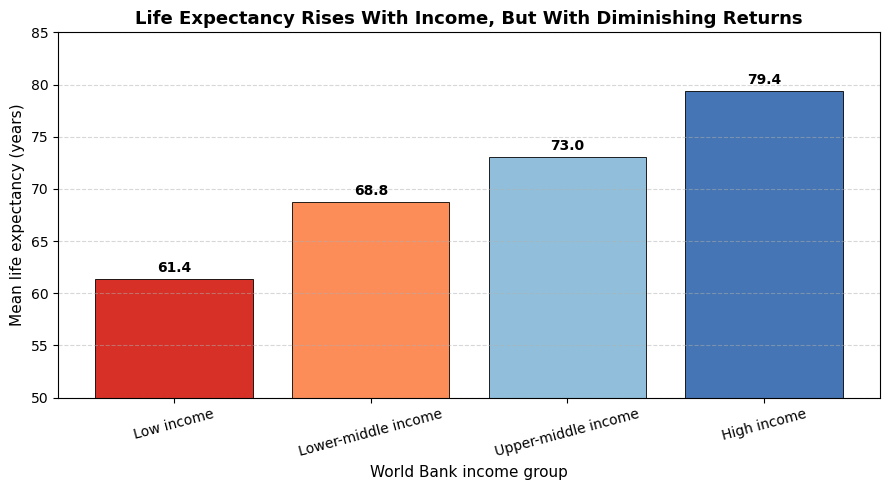

In [9]:
# Plot 1: Customized bar chart of mean life expectancy by income group (from Part 4)
fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = ["#d73027", "#fc8d59", "#91bfdb", "#4575b4"]
bars = ax.bar(income_summary.index, income_summary["mean_life_expectancy"], color=bar_colors, edgecolor="black", linewidth=0.6)

# Annotate each bar with its value
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.4, f"{height:.1f}", ha="center", va="bottom", fontweight="bold")

ax.set_title("Life Expectancy Rises With Income, But With Diminishing Returns", fontsize=13, fontweight="bold")
ax.set_xlabel("World Bank income group", fontsize=11)
ax.set_ylabel("Mean life expectancy (years)", fontsize=11)
ax.set_ylim(50, 85)
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

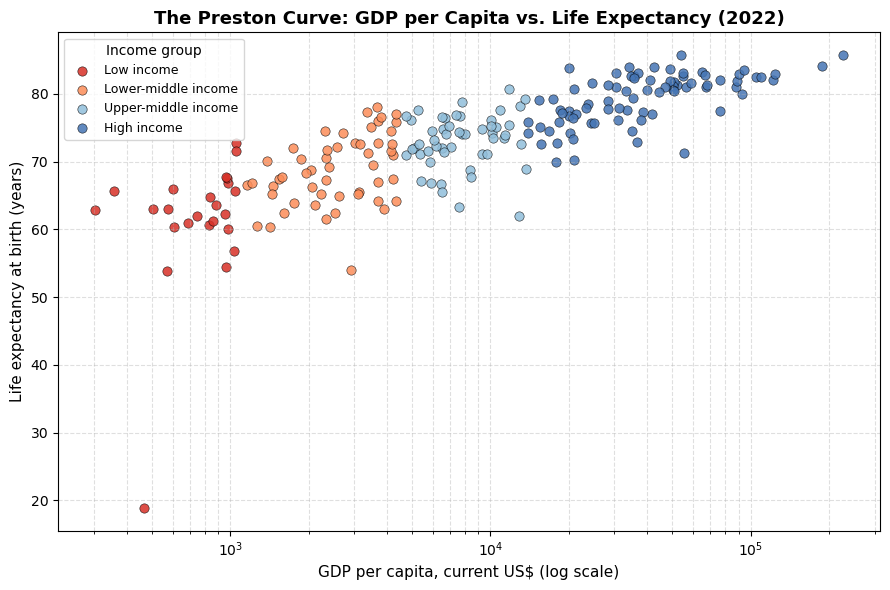

In [10]:
# Plot 2: Customized scatter of the two primary indicators (the Preston curve)
fig, ax = plt.subplots(figsize=(9, 6))
group_colors = {"Low income": "#d73027", "Lower-middle income": "#fc8d59", "Upper-middle income": "#91bfdb", "High income": "#4575b4"}
for group, color in group_colors.items():
    subset = merged[merged["income_group"] == group]
    ax.scatter(subset["gdp_per_capita"], subset["life_expectancy"], s=45, color=color, edgecolor="black", linewidth=0.4, alpha=0.85, label=group)

ax.set_xscale("log")
ax.set_title("The Preston Curve: GDP per Capita vs. Life Expectancy (2022)", fontsize=13, fontweight="bold")
ax.set_xlabel("GDP per capita, current US$ (log scale)", fontsize=11)
ax.set_ylabel("Life expectancy at birth (years)", fontsize=11)
ax.grid(True, which="both", linestyle="--", alpha=0.4)
ax.legend(title="Income group", fontsize=9)
plt.tight_layout()
plt.show()

                            OLS Regression Results                            
Dep. Variable:        life_expectancy   R-squared:                       0.627
Model:                            OLS   Adj. R-squared:                  0.625
Method:                 Least Squares   F-statistic:                     348.0
Date:                Wed, 10 Jun 2026   Prob (F-statistic):           3.24e-46
Time:                        03:07:28   Log-Likelihood:                -626.05
No. Observations:                 209   AIC:                             1256.
Df Residuals:                     207   BIC:                             1263.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         34.4224      2.101     16.386      0.0

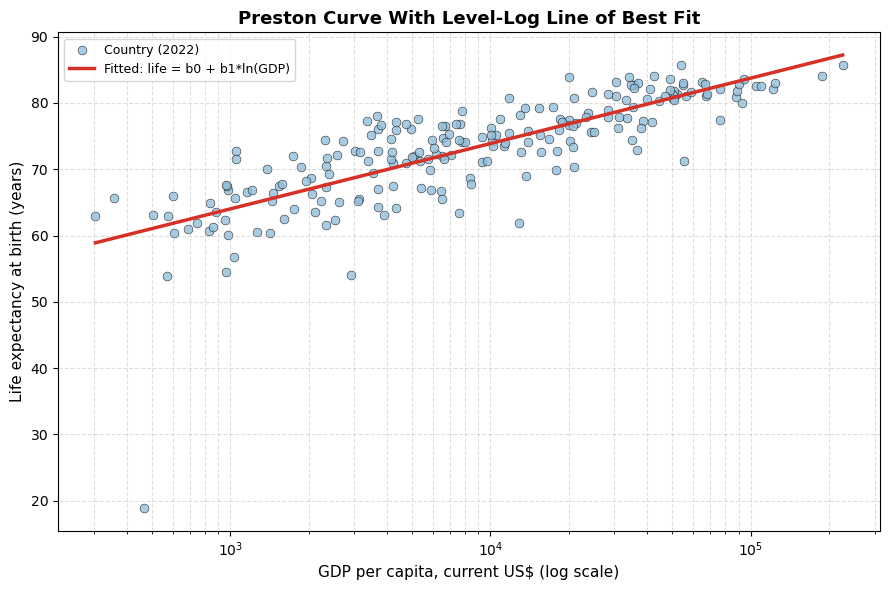


Slope on ln(GDP per capita): 4.28
Interpretation: a 1% rise in GDP per capita is associated with about 0.043 extra years of life expectancy.
R-squared: 0.627


In [11]:
# Fit a simple linear regression and overlay the line of best fit
# Level-Log model: life_expectancy = b0 + b1 * ln(gdp_per_capita)
model_df = merged.copy()
model_df["log_gdp"] = np.log(model_df["gdp_per_capita"])

X = sm.add_constant(model_df["log_gdp"])
y = model_df["life_expectancy"]
result = sm.OLS(y, X).fit()
print(result.summary())

# Overlay the fitted curve on the scatter plot
ordered = model_df.sort_values("gdp_per_capita")
predicted = result.predict(sm.add_constant(ordered["log_gdp"]))

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(model_df["gdp_per_capita"], model_df["life_expectancy"], s=40, color="#91bfdb", edgecolor="black", linewidth=0.4, alpha=0.8, label="Country (2022)")
ax.plot(ordered["gdp_per_capita"], predicted, color="#d73027", linewidth=2.5, label="Fitted: life = b0 + b1*ln(GDP)")

ax.set_xscale("log")
ax.set_title("Preston Curve With Level-Log Line of Best Fit", fontsize=13, fontweight="bold")
ax.set_xlabel("GDP per capita, current US$ (log scale)", fontsize=11)
ax.set_ylabel("Life expectancy at birth (years)", fontsize=11)
ax.grid(True, which="both", linestyle="--", alpha=0.4)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

slope = result.params["log_gdp"]
print(f"\nSlope on ln(GDP per capita): {slope:.2f}")
print(f"Interpretation: a 1% rise in GDP per capita is associated with about {slope / 100:.3f} extra years of life expectancy.")
print(f"R-squared: {result.rsquared:.3f}")

**Visualization + regression interpretation:**

- **Visuals:** The bar chart shows mean life expectancy climbing across income groups, and the scatter plot (on a log x-axis) reveals the characteristic Preston-curve shape — steep at low income, flattening at high income. Coloring points by income group makes the diminishing-returns pattern visually obvious.
- **Model choice:** Because the relationship is concave in raw dollars but roughly linear against *log* income, a **Level-Log** specification fits best: `life_expectancy = b0 + b1 * ln(gdp_per_capita)`.
- **Slope:** The positive, highly significant slope `b1` means each **doubling** of GDP per capita is associated with roughly `b1 * ln(2) ≈ 0.69 * b1` additional years of life (equivalently, a 1% income rise ≈ `b1/100` years). The high R² shows income alone explains much of the cross-country variation in longevity.
- **Caveat:** This is correlational, not causal — health spending, education, and institutions move alongside income. Still, the strong fit underscores why raising incomes in the poorest countries is among the most effective levers for improving population health.

### **Submission Checklist**

- **Out-of-the-Box Execution**
  - Select `Kernel -> Restart & Run All` to verify all cells run without error.
- **Reproducibility & Paths**
  - Verify that both the notebook and the dataset are saved and committed in Git.
  - Ensure all files are loaded using relative paths.
- **Visual Elements & Design**
  - Ensure all plots are fully customized, clearly labeled, and have titles.